In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

import sys
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))
import cosmo_kb_func as kbf

In [2]:
chain_dir = "../../../NA_zenodo/hierarchical_inference_chains/observed/"

# --- 1. Results Analysis and Visualization based on corner ---
file_name = os.path.join(chain_dir, "subsamples/bpl_slacs_only_chain.npz")
data = np.load(file_name)
remove_list = data['remove_list']
samples_all = data['samples']
lnprob_all = data["lnprob"]
print(f"Data shape from "+file_name+f": {samples_all.shape}")
print(f"--- Dropped data with index: {remove_list} ---") 

nburn = 300
samples_sub = samples_all[:,nburn:,:]
print(f"Sampling chain shape (after removing burn-in): {samples_sub.shape}")

ndim = samples_sub.shape[-1]
labels = ["$\\gamma_{PPN}$", "$\\beta_{0}$", "$\\beta_{z}$", "$\\tau_\\beta$", "$\\delta_{m,0}$","$\\delta_{m,z}$"]
samples0 = samples_sub.reshape(-1,ndim)

Data shape from ../../../NA_zenodo/hierarchical_inference_chains/observed/subsamples/bpl_slacs_only_chain.npz: (2000, 600, 6)
--- Dropped data with index: [101 107 108 114] ---
Sampling chain shape (after removing burn-in): (2000, 300, 6)


In [3]:
# --- 1. Results Analysis and Visualization based on corner ---
file_name = os.path.join(chain_dir, "subsamples/bpl_q_gt_0p6_chain.npz")
data = np.load(file_name)
remove_list = data['remove_list']
samples_all = data['samples']
lnprob_all = data["lnprob"]
print(f"Data shape from "+file_name+f": {samples_all.shape}")
print(f"--- Dropped data with index: {remove_list} ---") 

nburn = 301
samples_sub = samples_all[:,nburn:,:]
print(f"Sampling chain shape (after removing burn-in): {samples_sub.shape}")

ndim = samples_sub.shape[-1]
labels = ["$\\gamma_{PPN}$", "$\\beta_{0}$", "$\\beta_{z}$", "$\\tau_\\beta$", "$\\delta_{m,0}$","$\\delta_{m,z}$"]
samples1 = samples_sub.reshape(-1,ndim)

Data shape from ../../../NA_zenodo/hierarchical_inference_chains/observed/subsamples/bpl_q_gt_0p6_chain.npz: (2000, 600, 6)
--- Dropped data with index: [101 107 108 114  21  30  40  41  46  48  66  67  73  99 100 101 121] ---
Sampling chain shape (after removing burn-in): (2000, 299, 6)


In [4]:
# --- 1. Results Analysis and Visualization based on corner ---
file_name = os.path.join(chain_dir, "subsamples/bpl_no_cluster_chain.npz")
data = np.load(file_name)
remove_list = data['remove_list']
samples_all = data['samples']
lnprob_all = data["lnprob"]
print(f"Data shape from "+file_name+f": {samples_all.shape}")
print(f"--- Dropped data with index: {remove_list} ---") 

nburn = 302
samples_sub = samples_all[:,nburn:,:]
print(f"Sampling chain shape (after removing burn-in): {samples_sub.shape}")

ndim = samples_sub.shape[-1]
labels = ["$\\gamma_{PPN}$", "$\\beta_{0}$", "$\\beta_{z}$", "$\\tau_\\beta$", "$\\delta_{m,0}$","$\\delta_{m,z}$"]
samples2 = samples_sub.reshape(-1,ndim)

Data shape from ../../../NA_zenodo/hierarchical_inference_chains/observed/subsamples/bpl_no_cluster_chain.npz: (2000, 600, 6)
--- Dropped data with index: [101 107 108 114   6   7   8  16  24  26  27  31  41  57  60  70 100] ---
Sampling chain shape (after removing burn-in): (2000, 298, 6)


In [5]:
from getdist import plots, MCSamples  
# --- 2. Define parameter names and labels ---  
labels = [r"\gamma_{PPN}", r"\beta_0", r"\beta_z", r"\tau_\beta", r"\delta_{m,0}", r"\delta_{m,z}"]
ndim = len(labels)
# names are the parameter names used internally by getdist
names = [f"par{i+1}" for i in range(ndim)]  

# --- 3. Create the getdist MCSamples object ---  
limits = [ (0.65, 1.35), (None, None), (None, None), (0.02, None), (-1, 2), (-2, 2)] 
mcsamples0 = MCSamples(  
    samples=samples0,  
    names=names,  
    labels=labels,  
    label='MCMC posterior',  
    ranges=limits,
    settings={"smooth_scale_2D": 0.3, "smooth_scale_1D": 0.3}
)  

mcsamples1 = MCSamples(  
    samples=samples1,  
    names=names,  
    labels=labels,  
    label='MCMC posterior',  
    ranges=limits,
    settings={"smooth_scale_2D": 0.3, "smooth_scale_1D": 0.3}
)  

mcsamples2 = MCSamples(  
    samples=samples2,  
    names=names,  
    labels=labels,  
    label='MCMC posterior',  
    ranges=limits,
    settings={"smooth_scale_2D": 0.3, "smooth_scale_1D": 0.3}
)  

Removed no burn in
Removed no burn in
Removed no burn in


In [6]:
perc0,txt0 = kbf.get_mcmc_title(mcsamples0,weight=True,fmt=[".3f"])
perc1,txt1 = kbf.get_mcmc_title(mcsamples1,weight=True,fmt=[".3f"])
perc2,txt2 = kbf.get_mcmc_title(mcsamples2,weight=True,fmt=[".3f"])
perc,txt = perc2,txt2
#perc0,txt0,perc1,txt1,perc2,txt2

# lnprob_all = data['lnprob']
# idx = np.where(lnprob_all == lnprob_all.max())
# best_samples, best_lnprobs = samples_all[idx],lnprob_all[idx]
# best_samples, best_lnprobs


Generating triangle plot with getdist...


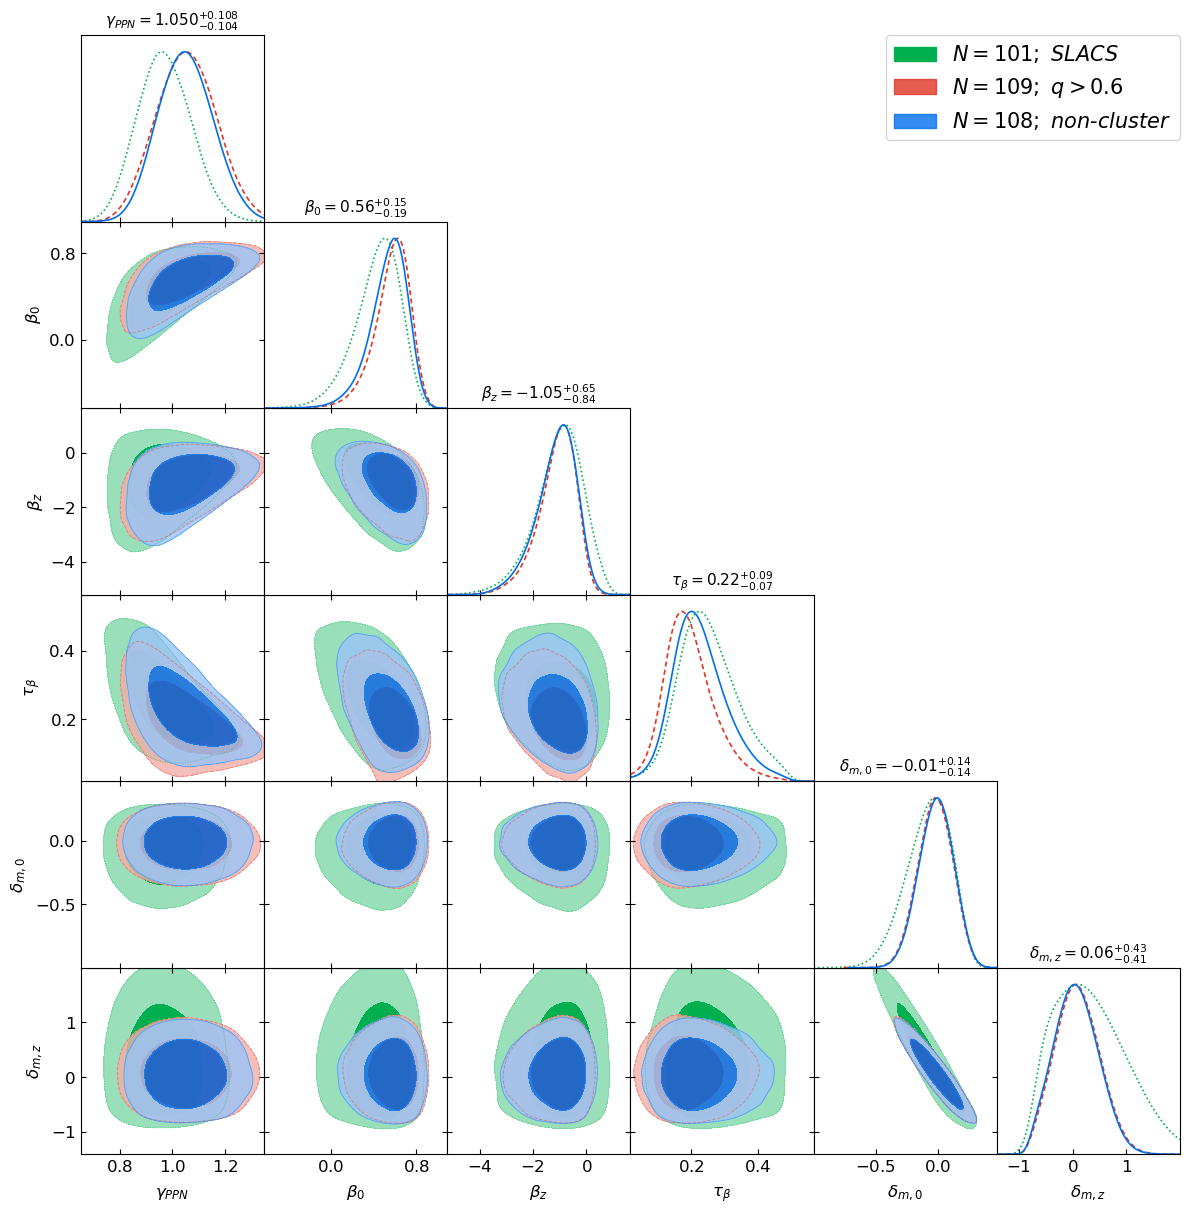

In [7]:
# --- 5. Plotting with getdist ---  
print("\nGenerating triangle plot with getdist...") 
g = plots.GetDistPlotter()  

# Set plot styles, such as line width, etc. 
g.settings.axes_labelsize = 15#12  
g.settings.axes_fontsize = 15#12  
g.settings.legend_fontsize = 18#12  
#g.settings.title_limit_fontsize = 12  
g.settings.alpha_filled_add = 0.8

# Plot the triangle plot (corner plot)  
g.triangle_plot(   
    [mcsamples0,mcsamples1,mcsamples2],      # Pass a list of MCSamples objects for comparison 
    #filled=True,     # Fill 2D contour plots   
    filled=[True,True,True],     # Fill 2D contour plots
    # #shaded=True,
    contour_colors=['#00B050','#e03424',"#006fed"],    #
    legend_labels=[r"$N=101;~SLACS$", r"$N=109;~q>0.6$", r"$N=108;~non$-$cluster$"],
    show_titles=True,
    title_limit=0,
    contour_lws = [1.2,1.2,1.2],
    contour_ls  = [':','--','-'],
    legend_loc='upper right'
)  

# #for i, name in enumerate(param_names):
for i in range(ndim):
    ax = g.subplots[i, i]
    ax.set_title(txt[i], fontsize=11)

# We start the loop from i=1 because the first parameter (i=0) only appears 
# as an X-axis and has no corresponding Y-axis to modify.
for i in range(1, ndim):
    x_axis_subplot = g.subplots[i, i]  
    y_axis_subplot = g.subplots[i, 0]
    
    # Get the limits and ticks from the source X-axis.
    x_lims = x_axis_subplot.get_xlim()
    x_ticks = x_axis_subplot.get_xticks()
    
    # This print statement is for verification purposes.
    # print(f"Parameter '{names[i]}': Got limits {x_lims} and ticks {x_ticks} from its X-axis.")
    # Apply these limits and ticks to the corresponding Y-axis.
    y_axis_subplot.set_ylim(x_lims)
    y_axis_subplot.set_yticks(x_ticks)

#plt.tight_layout()
plt.savefig('sup_fig3_sensitivity_sample.pdf', dpi=400, bbox_inches='tight')
#plt.savefig('sup_fig3_sensitivity_sample.png', dpi=400, bbox_inches='tight')
plt.show()